In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from imblearn.over_sampling import SMOTE
import joblib
import shap
import os
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Create directories for saving artifacts
os.makedirs('../data/processed', exist_ok=True)
os.makedirs('../reports/figures', exist_ok=True)
os.makedirs('../models', exist_ok=True)

In [3]:
# 1. Load Data
df = pd.read_csv('../data/raw/breast_cancer_prediction.csv')
print("Initial Shape:", df.shape)
df.head()

Initial Shape: (10000, 23)


,Patient_ID,Age,Gender,BMI,Family_History,Smoking,Alcohol_Consumption,Physical_Activity,Hormone_Therapy,Menopause_Status,...,Mammogram_Result,Biopsy_Result,Cancer_Stage,Cancer,Blood_Pressure,Cholesterol,Diabetes,Exercise_Days_Per_Week,Breastfeeding_History,Annual_Income_USD
0,100001,71,Female,27.2,Yes,Yes,Yes,High,No,Post,...,Suspicious,Malignant,Stage II,1,141,167,No,7,No,101316
1,100002,34,Male,26.0,No,No,No,High,No,Post,...,Normal,Benign,No Cancer,0,104,229,Yes,7,Yes,30023
2,100003,80,Female,20.7,No,No,No,High,No,Pre,...,Suspicious,Benign,No Cancer,0,161,275,No,1,Yes,34819
3,100004,40,Female,26.8,Yes,Yes,No,Moderate,No,Post,...,Normal,Benign,No Cancer,0,150,180,No,7,Yes,68025
4,100005,43,Female,28.6,Yes,Yes,No,Moderate,No,Post,...,Normal,Benign,No Cancer,0,110,266,No,0,Yes,90919


In [4]:
# 2. Data Cleaning
# Remove duplicates
df.drop_duplicates(inplace=True)

# Checking missing values
print("Missing values:\n", df.isnull().sum())
df.dropna(inplace=True)

# Drop Patient_ID and leaky features
cols_to_drop = ['Patient_ID', 'Biopsy_Result', 'Cancer_Stage']
for col in cols_to_drop:
    if col in df.columns:
        df.drop(col, axis=1, inplace=True)

Missing values:
 Patient_ID                  0
Age                         0
Gender                      0
BMI                       300
Family_History              0
Smoking                     0
Alcohol_Consumption       300
Physical_Activity         300
Hormone_Therapy           300
Menopause_Status            0
Genetic_Mutation            0
Tumor_Size_cm             300
Lymph_Node_Involvement      0
Mammogram_Result            0
Biopsy_Result               0
Cancer_Stage                0
Cancer                      0
Blood_Pressure              0
Cholesterol                 0
Diabetes                    0
Exercise_Days_Per_Week      0
Breastfeeding_History       0
Annual_Income_USD           0
dtype: int64


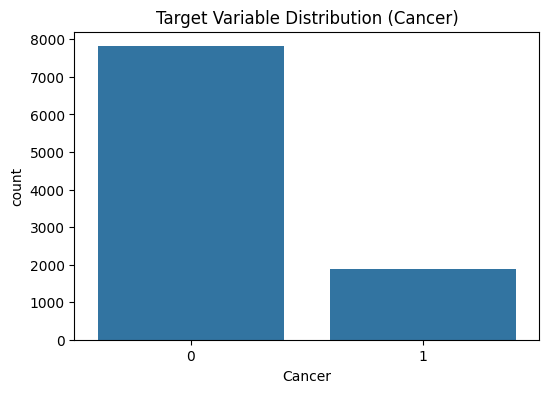

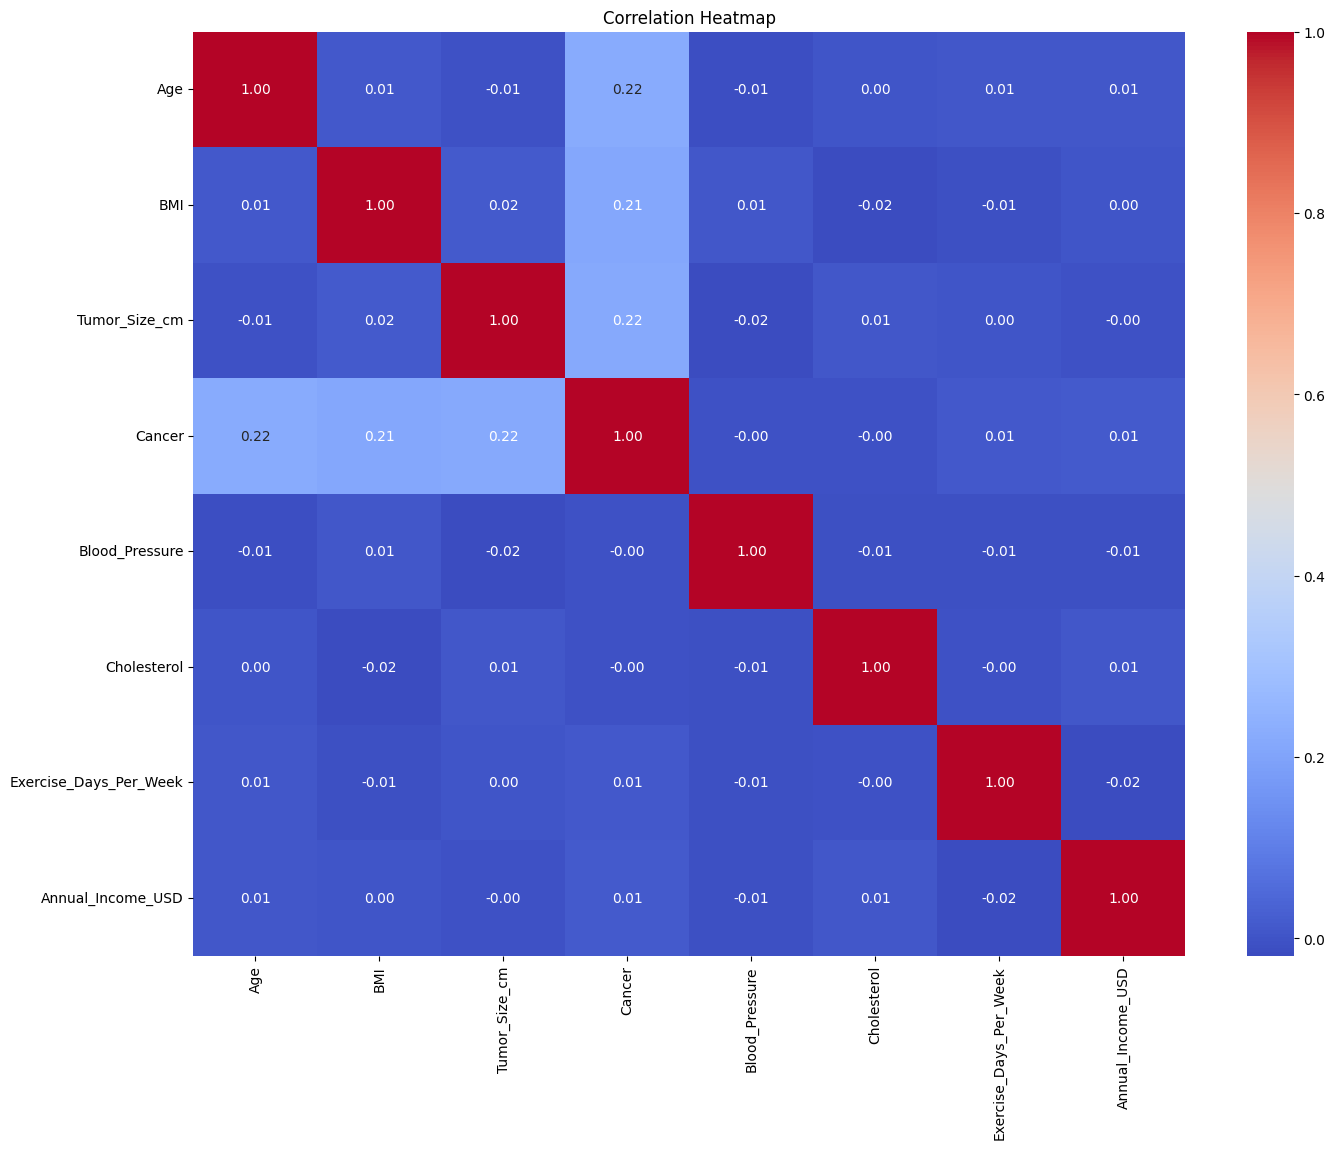

In [5]:
# 3. Exploratory Data Analysis
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Cancer')
plt.title('Target Variable Distribution (Cancer)')
plt.savefig('../reports/figures/target_distribution.png')
plt.show()

# Correlation Heatmap
plt.figure(figsize=(16, 12))
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
sns.heatmap(df[numerical_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.savefig('../reports/figures/correlation_heatmap.png')
plt.show()

In [6]:
# 4. Feature Engineering & Encoding
categorical_cols = df.select_dtypes(include=['object']).columns
label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

joblib.dump(label_encoders, '../models/label_encoders.pkl')

# Train-Test Split Setup
X = df.drop('Cancer', axis=1)
y = df['Cancer']

In [7]:
# 5. SMOTE & Scaling
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)
print("Shape after SMOTE:", X_resampled.shape)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_resampled)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)
joblib.dump(scaler, '../models/scaler.pkl')

# Save Processed Data
processed_df = pd.concat([X_scaled_df, pd.Series(y_resampled, name='Cancer')], axis=1)
processed_df.to_csv('../data/processed/breast_cancer_processed.csv', index=False)

Shape after SMOTE: (15626, 19)


In [8]:
# 6. Model Training
X_train, X_test, y_train, y_test = train_test_split(X_scaled_df, y_resampled, test_size=0.2, random_state=42)

models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(random_state=42)
}

results = []
best_model = None
best_f1 = 0

print("Evaluating Models...")
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_prob) if y_prob is not None else 'N/A'
    
    results.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1 Score': f1,
        'ROC AUC': roc
    })
    
    if f1 > best_f1:
        best_f1 = f1
        best_model = model

results_df = pd.DataFrame(results)
print("\nModel Comparison:")
display(results_df)

Evaluating Models...

Model Comparison:


,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.789827,0.778485,0.798303,0.788269,0.872222
1,Random Forest,0.874280,0.866238,0.879243,0.872692,0.944133


In [9]:
# Hyperparameter Tuning for Best Model (Random Forest)
if isinstance(best_model, RandomForestClassifier):
    print("\nTuning Random Forest...")
    param_grid = {
        'n_estimators': [100, 200],
        'max_depth': [None, 10, 20],
        'min_samples_split': [2, 5]
    }
    grid_search = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=3, scoring='f1', n_jobs=-1)
    grid_search.fit(X_train, y_train)
    
    best_model = grid_search.best_estimator_
    print(f"Best parameters: {grid_search.best_params_}")
    
    y_pred = best_model.predict(X_test)
    print(f"Tuned RF F1 Score: {f1_score(y_test, y_pred):.4f}")

joblib.dump(best_model, '../models/best_model.pkl')
print(f"\nSaved best model ({best_model.__class__.__name__}) to models/best_model.pkl")


Tuning Random Forest...
Best parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Tuned RF F1 Score: 0.8733

Saved best model (RandomForestClassifier) to models/best_model.pkl


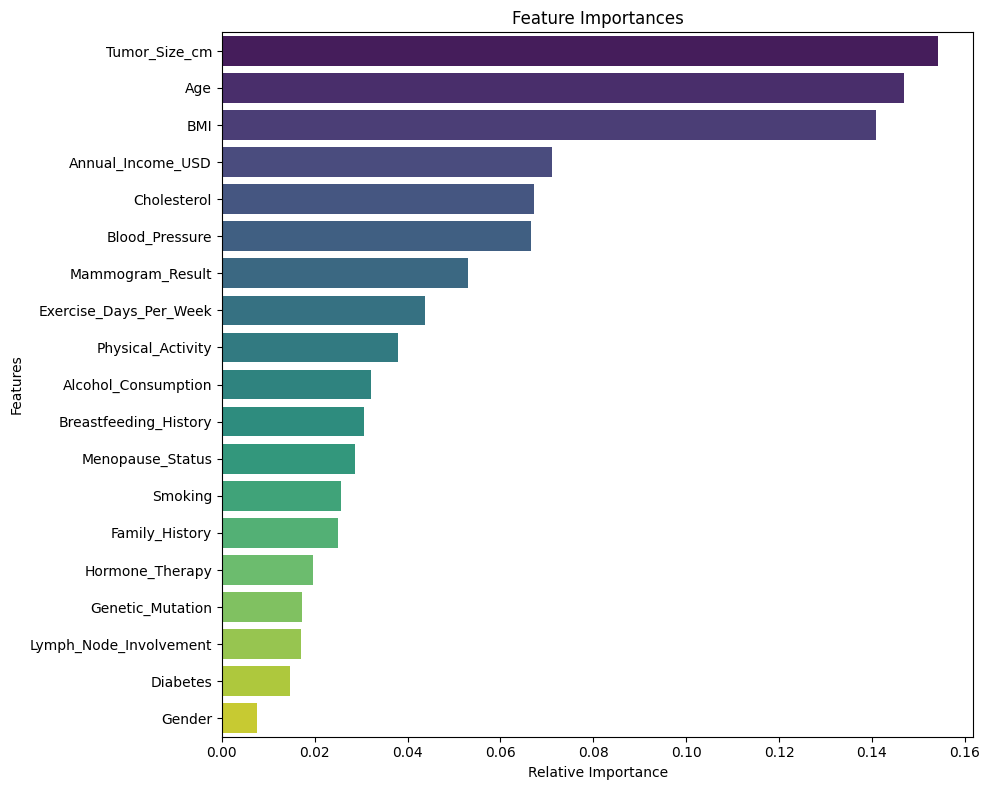

In [10]:
# 7. Explainability
if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
    features = X.columns
    
    indices = importances.argsort()[::-1]
    
    plt.figure(figsize=(10, 8))
    sns.barplot(x=importances[indices], y=[features[i] for i in indices], palette='viridis')
    plt.title('Feature Importances')
    plt.xlabel('Relative Importance')
    plt.ylabel('Features')
    plt.tight_layout()
    plt.savefig('../reports/figures/feature_importance.png')
    plt.show()

<Figure size 1000x800 with 0 Axes>

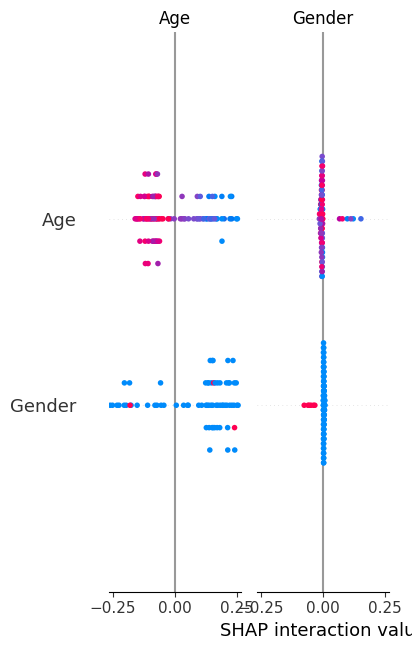

In [11]:
# SHAP Values
# Use a background dataset for shap
X_sample = shap.utils.sample(X_scaled_df, 100)

if hasattr(best_model, 'feature_importances_'):
    explainer = shap.TreeExplainer(best_model)
    shap_values = explainer.shap_values(X_sample)
    
    if isinstance(shap_values, list):
        shap_values_to_plot = shap_values[1]
    else:
        shap_values_to_plot = shap_values
else:
    explainer = shap.LinearExplainer(best_model, X_sample)
    shap_values = explainer.shap_values(X_sample)
    shap_values_to_plot = shap_values

plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values_to_plot, X_sample, show=False)
plt.tight_layout()
plt.savefig('../reports/figures/shap_summary.png')
plt.show()